In [ ]:
!pip install -r requirements.txt -q
!pip install pyvirtualdisplay

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 80.3 MB/s eta 0:00:00




---




**Test a random policy on the Gym Hopper environment**

\



Play around with this code to get familiar with the
Hopper environment.

For example, what happens if you don't reset the environment
even after the episode is over?
When exactly is the episode over?
What is an action here?

In [ ]:
import gymnasium as gym

In [ ]:
env = gym.make('Hopper-v4', render_mode='rgb_array')

print('State space:', env.unwrapped.observation_space)  # state-space
print('Action space:', env.action_space)  # action-space

State space: Box(-inf, inf, (11,), float64)
Action space: Box(-1.0, 1.0, (3,), float32)


/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


In [ ]:
for i in range(env.unwrapped.model.nbody):
    print(env.unwrapped.model.body(i).name, env.unwrapped.model.body_mass[i])

world 0.0
torso 3.6651914291880923
thigh 4.057890510886818
leg 2.7813566959781637
foot 5.315574769873931


In [ ]:
n_episodes = 5

for episode in range(n_episodes):
  done = False
  observation = env.reset()	 # Reset environment to initial state

  while not done:  # Until the episode is over

    action = env.action_space.sample()	# Sample random action

    observation, reward, terminated, truncated, _ = env.step(action)	# Step the simulator to the next
    done = terminated or truncated


# Rendering
Interactive simulation are difficult to run but you can use rgb array as rendering mode to obtain an image. You can create videos later if you render at each timestamp.

In [ ]:
from IPython.display import HTML
from IPython import display as ipythondisplay
from pyvirtualdisplay import Display

# Start virtual display
display = Display(visible=0, size=(1400, 900))
display.start()

In [ ]:
res = env.render()


array([[[ 67,  84, 101],
        [ 67,  84, 101],
        [ 67,  84, 101],
        ...,
        [ 67,  84, 101],
        [ 67,  84, 101],
        [ 67,  84, 101]],

       [[ 67,  84, 101],
        [ 67,  84, 101],
        [ 67,  84, 101],
        ...,
        [ 67,  84, 101],
        [ 67,  84, 101],
        [ 67,  84, 101]],

       [[ 67,  84, 101],
        [ 67,  84, 101],
        [ 67,  84, 101],
        ...,
        [ 67,  84, 101],
        [ 67,  84, 101],
        [ 67,  84, 101]],

       ...,

       [[ 51,  56,  51],
        [ 51,  56,  51],
        [ 51,  56,  51],
        ...,
        [ 51,  56,  51],
        [ 51,  56,  51],
        [ 51,  56,  51]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]], dtype=uint8)
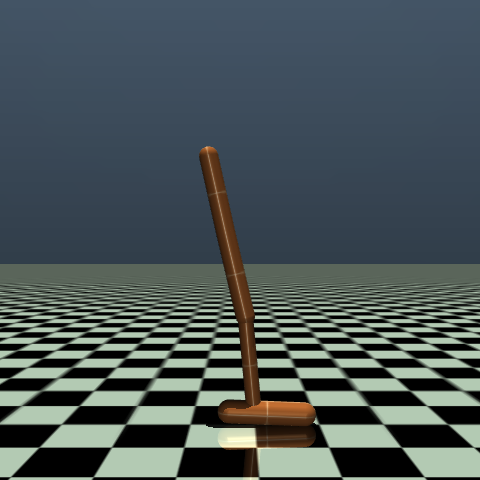

In [ ]:
res

#2 REINFORCE alg

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.distributions import Normal

In [ ]:
def discount_rewards(r, gamma):
    discounted_r = torch.zeros_like(r)
    running_add = 0
    for t in reversed(range(0, r.size(-1))):
        running_add = running_add * gamma + r[t]
        discounted_r[t] = running_add
    return discounted_r

In [ ]:
class Policy(torch.nn.Module):
    def __init__(self, state_space, action_space):
        super().__init__()
        self.state_space = state_space
        self.action_space = action_space
        self.hidden = 64
        self.tanh = torch.nn.Tanh()

        """
            Actor network
        """
        self.fc1_actor = torch.nn.Linear(state_space, self.hidden)
        self.fc2_actor = torch.nn.Linear(self.hidden, self.hidden)
        self.fc3_actor_mean = torch.nn.Linear(self.hidden, action_space)

        # Learned standard deviation for exploration at training time
        self.sigma_activation = F.softplus
        init_sigma = 0.5
        self.sigma = torch.nn.Parameter(torch.zeros(self.action_space)+init_sigma)

        self.init_weights()


    def init_weights(self):
        for m in self.modules():
            if type(m) is torch.nn.Linear:
                torch.nn.init.normal_(m.weight)
                torch.nn.init.zeros_(m.bias)


    def forward(self, x):
        """
            Actor
        """
        x_actor = self.tanh(self.fc1_actor(x))
        x_actor = self.tanh(self.fc2_actor(x_actor))
        action_mean = self.fc3_actor_mean(x_actor)

        sigma = self.sigma_activation(self.sigma)
        normal_dist = Normal(action_mean, sigma)

        return normal_dist

In [ ]:
class Agent(object):
    def __init__(self, policy, device='cpu'):
        self.train_device = device
        self.policy = policy.to(self.train_device)
        self.optimizer = torch.optim.Adam(policy.parameters(), lr=1e-3)

        self.gamma = 0.99
        self.states = []
        self.next_states = []
        self.action_log_probs = []
        self.rewards = []
        self.done = []


    def update_policy(self, baseline = 0):
        action_log_probs = torch.stack(self.action_log_probs, dim=0).to(self.train_device).squeeze(-1)
        states = torch.stack(self.states, dim=0).to(self.train_device).squeeze(-1)
        next_states = torch.stack(self.next_states, dim=0).to(self.train_device).squeeze(-1)
        rewards = torch.stack(self.rewards, dim=0).to(self.train_device).squeeze(-1)
        done = torch.Tensor(self.done).to(self.train_device)

        self.states, self.next_states, self.action_log_probs, self.rewards, self.done = [], [], [], [], []

        #
        # TASK 2:
        #   - compute discounted returns with baseline
        returns = discount_rewards(rewards, self.gamma) - baseline

        #   - compute policy gradient loss function given actions and returns
        policy_loss = -(action_log_probs * returns).sum()

        #   - compute gradients and step the optimizer
        self.optimizer.zero_grad()
        policy_loss.backward()
        self.optimizer.step()

        return


    def get_action(self, state, evaluation=False):
        """ state -> action (3-d), action_log_densities """
        x = torch.from_numpy(state).float().to(self.train_device)

        normal_dist = self.policy(x)

        if evaluation:  # Return mean
            return normal_dist.mean, None

        else:   # Sample from the distribution
            action = normal_dist.sample()

            # Compute Log probability of the action [ log(p(a[0] AND a[1] AND a[2])) = log(p(a[0])*p(a[1])*p(a[2])) = log(p(a[0])) + log(p(a[1])) + log(p(a[2])) ]
            action_log_prob = normal_dist.log_prob(action).sum()

            return action, action_log_prob


    def store_outcome(self, state, next_state, action_log_prob, reward, done):
        self.states.append(torch.from_numpy(state).float())
        self.next_states.append(torch.from_numpy(next_state).float())
        self.action_log_probs.append(action_log_prob)
        self.rewards.append(torch.Tensor([reward]))
        self.done.append(done)

training

In [ ]:
import gymnasium as gym

def training_reinforce(nb_episodes, baseline = 0):
    env = gym.make('Hopper-v4')

    #TODO: implement training loop for REINFORCE using the agent defined in agent.py
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]

    policy = Policy(state_dim, action_dim)
    agent = Agent(policy)
    episodes_reward = []
    history_data = []

    for episode in range(nb_episodes):
        state, _ = env.reset()
        done = False
        episode_reward = 0
        steps = 0

        while not done:
            # 1. Get action + log prob from policy
            action, log_prob = agent.get_action(state)
            action_np = action.detach().numpy()

            # 2. Step environment
            next_state, reward, terminated, truncated, _ = env.step(action_np)
            done = terminated or truncated

            # 3. Store transition
            agent.store_outcome(
                state=state,
                next_state=next_state,
                action_log_prob=log_prob,
                reward=reward,
                done=done
            )


            state = next_state
            steps += 1
            episode_reward += reward

        # 4. Policy update at end of episode
        loss = agent.update_policy(baseline)

        episodes_reward.append(episode_reward)
        history_data.append({
        "episode": episode,
        "reward": episode_reward,
        "steps": steps
          })

        if episode % 10 == 0:
          print(f"Episode {episode} stats")
          print(f"Reward: {episode_reward}")
          print(f"Step: {steps}")
          print("-" * 30)


    env.close()
    return history_data

Without baseline

In [ ]:
import pandas as pd
train_dat = training_reinforce(2000)
train_df = pd.DataFrame(train_dat)
train_df.head()

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Episode 0 stats
Reward: 2.998330022725172
Step: 8
------------------------------
Episode 10 stats
Reward: 2.9116339431360903
Step: 8
------------------------------
Episode 20 stats
Reward: 3.5673433637733103
Step: 8
------------------------------
Episode 30 stats
Reward: 3.8001642083814877
Step: 8
------------------------------
Episode 40 stats
Reward: 3.4848823527562454
Step: 8
------------------------------
Episode 50 stats
Reward: 3.0423785787303923
Step: 7
------------------------------
Episode 60 stats
Reward: 3.4562573272028825
Step: 8
------------------------------
Episode 70 stats
Reward: 3.4752800206464967
Step: 8
------------------------------
Episode 80 stats
Reward: 3.6075095681004723
Step: 8
------------------------------
Episode 90 stats
Reward: 3.7088096674492657
Step: 8
------------------------------
Episode 100 stats
Reward: 3.94463893906211
Step: 8
------------------------------
Episode 110 stats
Reward: 3.5106184785059984
Step: 8
------------------------------
Episod

,episode,reward,steps
0,0,2.998330,8
1,1,2.870025,8
2,2,3.381638,8
3,3,2.681100,7
4,4,4.134858,9


In [ ]:
import matplotlib.pyplot as plt

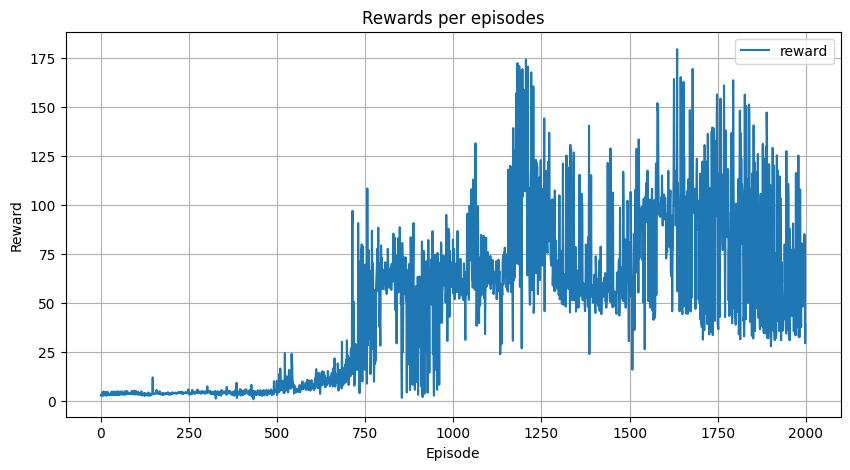

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_df["episode"], train_df["reward"], label="reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Rewards per episodes")
plt.grid(True)
plt.legend()
plt.show()

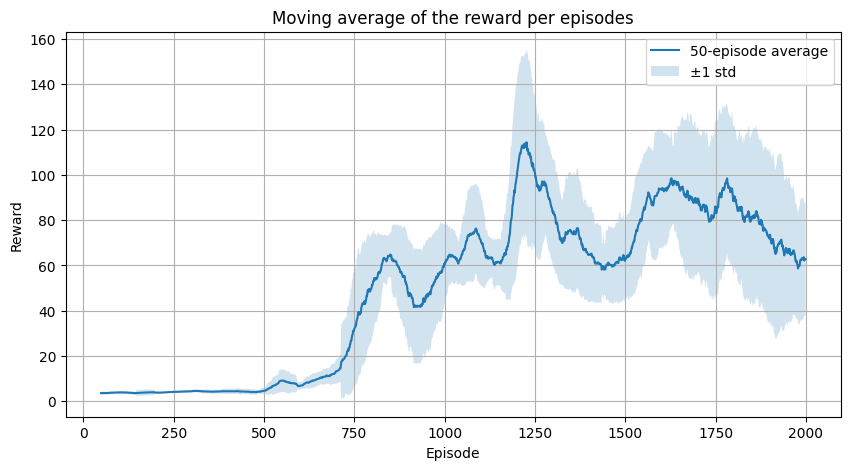

In [ ]:
window = 50
moving_avg = train_df["reward"].rolling(window=window).mean()
moving_std = train_df["reward"].rolling(window=window).std()

plt.figure(figsize=(10, 5))
plt.plot(train_df["episode"], moving_avg, label="50-episode average")
plt.fill_between(train_df["episode"], moving_avg - moving_std, moving_avg + moving_std, alpha=0.2, label="±1 std")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Moving average of the reward per episodes")
plt.grid(True)
plt.legend()
plt.show()

With baseline b = 20

In [ ]:
import pandas as pd
train_dat= training_reinforce(2000,20)
train_df = pd.DataFrame(train_dat)
train_df.head()

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Episode 0 stats
Reward: 21.105280339689216
Step: 25
------------------------------
Episode 10 stats
Reward: 11.897517875019789
Step: 19
------------------------------
Episode 20 stats
Reward: 9.652081109607845
Step: 16
------------------------------
Episode 30 stats
Reward: 10.088236039447827
Step: 14
------------------------------
Episode 40 stats
Reward: 19.661487561310047
Step: 25
------------------------------
Episode 50 stats
Reward: 5.964504064320779
Step: 10
------------------------------
Episode 60 stats
Reward: 15.798632367108182
Step: 23
------------------------------
Episode 70 stats
Reward: 19.786915407097123
Step: 24
------------------------------
Episode 80 stats
Reward: 9.113356959674773
Step: 15
------------------------------
Episode 90 stats
Reward: 3.5057695720021123
Step: 8
------------------------------
Episode 100 stats
Reward: 11.859590208984429
Step: 16
------------------------------
Episode 110 stats
Reward: 10.520699109408016
Step: 15
--------------------------

,episode,reward,steps
0,0,21.105280,25
1,1,9.638858,15
2,2,9.516609,15
3,3,12.817565,18
4,4,11.348755,14


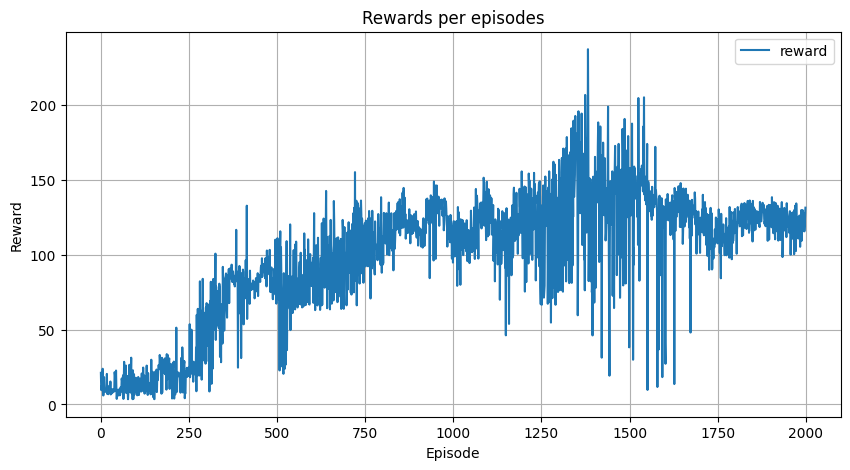

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_df["episode"], train_df["reward"], label="reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Rewards per episodes")
plt.grid(True)
plt.legend()
plt.show()

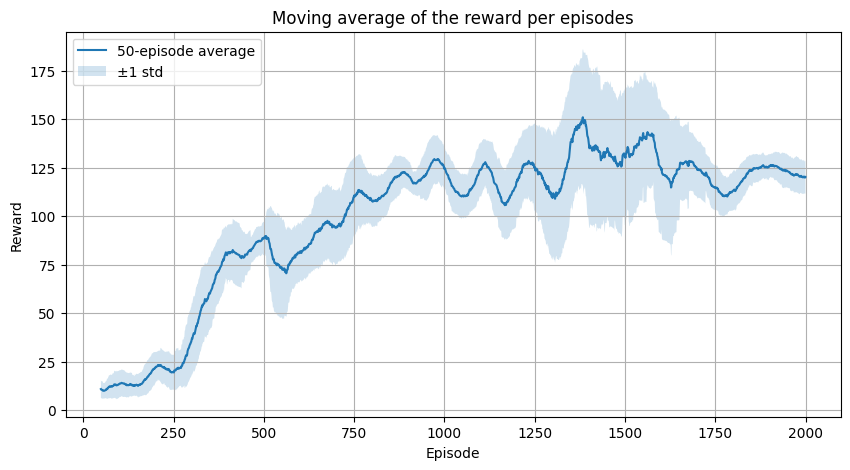

In [ ]:
window = 50
moving_avg = train_df["reward"].rolling(window=window).mean()
moving_std = train_df["reward"].rolling(window=window).std()

plt.figure(figsize=(10, 5))
plt.plot(train_df["episode"], moving_avg, label="50-episode average")
plt.fill_between(train_df["episode"], moving_avg - moving_std, moving_avg + moving_std, alpha=0.2, label="±1 std")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Moving average of the reward per episodes")
plt.grid(True)
plt.legend()
plt.show()

# 3. Actor Critic alg

In [ ]:
!pip install "gymnasium[mujoco]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 657.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 17.4 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as fun
import torch. optim as optim
from torch.distributions import Normal
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Initial responses


In [ ]:
env = gym.make('Hopper-v4', render_mode='rgb_array')
print("ob space ", env.observation_space)
print("act space " , env.action_space)

unwrapped_model= env.unwrapped.model
print("# deg freedom ", unwrapped_model.nv)
print("# deg free body ", unwrapped_model.body_dofnum)
print("# actuators ", unwrapped_model.nu)




/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


ob space  Box(-inf, inf, (11,), float64)
act space  Box(-1.0, 1.0, (3,), float32)
# deg freedom  6
# deg free body  [0 3 1 1 1]
# actuators  3


In [ ]:
# Masas
for i in range(unwrapped_model.nbody):
    print(unwrapped_model.body(i).name, unwrapped_model.body_mass[i])

NameError: name 'unwrapped_model' is not defined

## Actor- critic clases imp

In [ ]:
class actor(nn.Module):
  def __init__(self, dim_state, dim_action):
    super().__init__()
    self.net= nn.Sequential(
        nn.Linear(dim_state,64),
        nn.Tanh(),
        nn.Linear(64,64),
        nn.Tanh()
    )
    self.mean= nn.Linear(64, dim_action)
    self.std_log= nn.Parameter(torch.zeros(dim_action))

  def forward(self, state):
    x= self.net(state)
    mean= self.mean(x)
    std= torch.exp(self.std_log)
    return mean,std

  def get_action(self, state):
    mean,std= self.forward(state)
    dist= Normal(mean,std)

    action= dist.sample()
    probability_log= dist.log_prob(action).sum(dim=-1)
    action= torch.clamp(action,-1.0,1.0)

    return action, probability_log


In [ ]:
class critic(nn.Module):
  def __init__(self,dim_state):
    super().__init__()
    self.net= nn.Sequential(
        nn.Linear(dim_state,64),
        nn.Tanh(),
        nn.Linear(64,64),
        nn.Tanh(),
        nn.Linear(64,1)
        )
  def forward(self, state):
    return self.net(state).squeeze(-1)

In [ ]:
class action_critic_agent:
  def __init__(self,dim_state,dim_action, lr=3e-3, gamma=0.9):
    self.actor= actor(dim_state,dim_action)
    self.critic= critic(dim_state)

    self.actor_optim= optim.Adam(self.actor.parameters(), lr=lr)
    self.critic_optim= optim.Adam(self.critic.parameters(), lr=lr)

    self.gamma= gamma
  def select_act(self, state):
    state= torch.tensor(state, dtype=torch.float32)
    action, prob_log= self.actor.get_action(state)
    val= self.critic(state)

    return action.detach().numpy(), prob_log, val

  def computate_rets(self,rewards):
    rets=[]
    r=0

    for reward in rewards[::-1]:
      r= reward+ (self.gamma*r)
      rets.insert(0,r)

    rets= torch.tensor(rets, dtype= torch.float32)
    return rets

  def update(self, rewards,prob_logs, values):
    rets= self.computate_rets(rewards)
    log_probss= torch.stack(prob_logs)
    valuess= torch.stack(values)

    advantages= rets - valuess

    actor_loss= -(log_probss* advantages.detach()).mean()
    critic_loss= fun.mse_loss(valuess, rets)

    self.actor_optim.zero_grad()
    actor_loss.backward()
    self.actor_optim.step()

    self.critic_optim.zero_grad()
    critic_loss.backward()
    self.critic_optim.step()

    return actor_loss.item(), critic_loss.item()



## training

In [ ]:
def train(episodes, max_steps, lr=1e-3, gamma=0.9):
  env = gym.make('Hopper-v4', render_mode='rgb_array')

  dim_state= env.observation_space.shape[0]
  dim_action= env.action_space.shape[0]

  agent= action_critic_agent(dim_state,dim_action,lr=lr, gamma=gamma)

  episode_rewards=[]
  history_data=[]

  for episode in range(episodes):
    state,info= env.reset()

    rewards=[]
    prob_logs=[]
    values=[]

    total_reward=0

    for step in range(max_steps):
      action,prob_log, val= agent.select_act(state)
      next_state,reward, terminated, truncated,info= env.step(action)


      rewards.append(reward)
      prob_logs.append(prob_log)
      values.append(val)

      total_reward+=reward
      state=next_state

      if terminated:
          done_type = "terminated"
          break

      if truncated:
          done_type = "truncated"
          break

    actor_loss, critic_loss= agent.update(rewards, prob_logs, values)

    episode_rewards.append(total_reward)
    history_data.append({
        "episode": episode,
        "reward": total_reward,
        "actor_loss": actor_loss,
        "critic_loss": critic_loss,
        "steps": step + 1,
        "done_type": done_type
    })

    if episode % 10 == 0:
        print(f"Episode {episode} stats")
        print(f"Reward: {total_reward}")
        print(f"Actor loss: {actor_loss}")
        print(f"Critic loss: {critic_loss}")
        print(f"Steps: {step + 1}")
        print(f"Done type: {done_type}")
        print("-" * 30)
  return history_data


In [ ]:
train_dat= train(500,1000)
train_df = pd.DataFrame(train_dat)
train_df.head()

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Episode 0 stats
Reward: 13.91127161636811
Actor loss: 17.472003936767578
Critic loss: 26.09726905822754
Steps: 15
Done type: terminated
------------------------------
Episode 10 stats
Reward: 16.470474979652447
Actor loss: 17.589859008789062
Critic loss: 27.083127975463867
Steps: 16
Done type: terminated
------------------------------
Episode 20 stats
Reward: 76.00290509816342
Actor loss: 53.094154357910156
Critic loss: 176.32962036132812
Steps: 47
Done type: terminated
------------------------------
Episode 30 stats
Reward: 98.67624186166961
Actor loss: 46.73433303833008
Critic loss: 139.6876220703125
Steps: 66
Done type: terminated
------------------------------
Episode 40 stats
Reward: 99.16581551446848
Actor loss: 58.281410217285156
Critic loss: 168.88194274902344
Steps: 56
Done type: terminated
------------------------------
Episode 50 stats
Reward: 106.34907747821302
Actor loss: 50.88745880126953
Critic loss: 163.0100860595703
Steps: 57
Done type: terminated
---------------------

,episode,reward,actor_loss,critic_loss,steps,done_type
0,0,13.911272,17.472004,26.097269,15,terminated
1,1,28.928167,30.087034,59.056957,28,terminated
2,2,14.244236,13.928248,19.844952,20,terminated
3,3,16.364136,24.739664,32.684505,16,terminated
4,4,18.809168,22.203253,32.778961,20,terminated


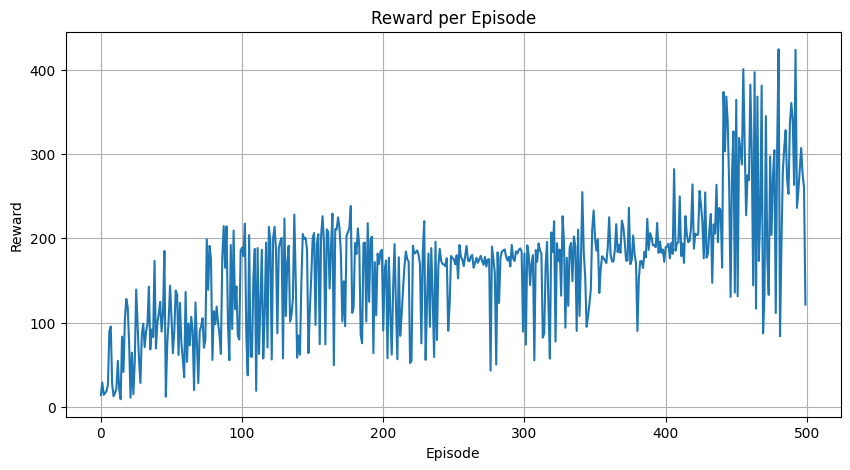

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_df["episode"], train_df["reward"])
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Reward per Episode")
plt.grid(True)
plt.show()

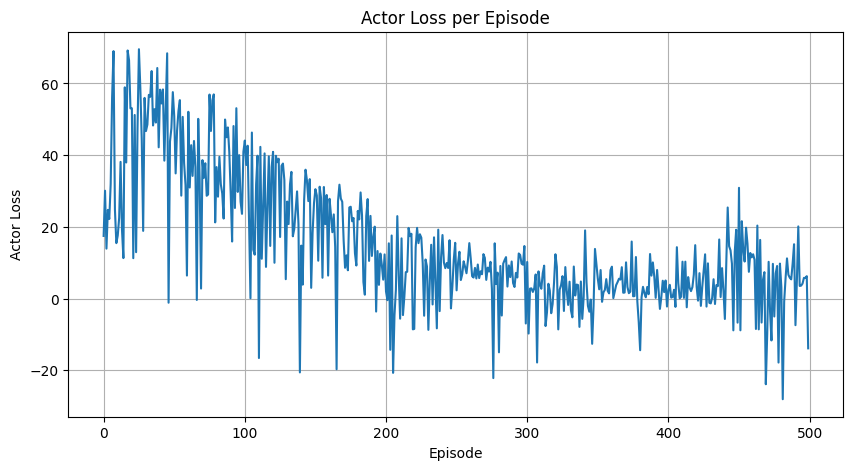

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_df["episode"], train_df["actor_loss"])
plt.xlabel("Episode")
plt.ylabel("Actor Loss")
plt.title("Actor Loss per Episode")
plt.grid(True)
plt.show()

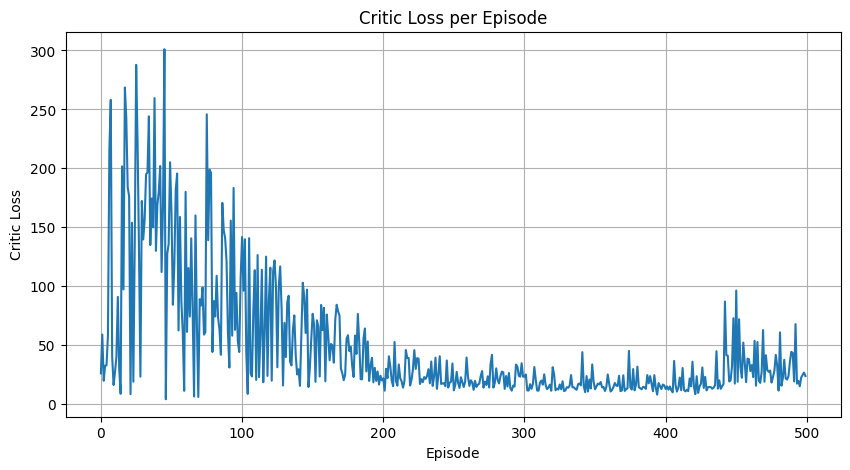

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_df["episode"], train_df["critic_loss"])
plt.xlabel("Episode")
plt.ylabel("Critic Loss")
plt.title("Critic Loss per Episode")
plt.grid(True)
plt.show()

##